In [ ]:
!pip install snowflake-connector-python pandas sci-kit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 984.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
import snowflake.connector
import pandas as pd


In [ ]:
con=snowflake.connector.connect(
    user='Shivaji',
    password='Shivaji11042007',
    account='PLFONYJ-PV16555',
    database='winequality',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)


In [ ]:
query='select * from winequalitydb'
df=pd.read_sql(query,con)

/tmp/ipykernel_2771/906016965.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [ ]:
df

,TYPE,FIXED_ACIDITY,VOLATILE_ACIDITY,CITRIC_ACID,RESIDUAL_SUGAR,CHLORIDES,FREE_SULFUR_DIOXIDE,TOTAL_SULFUR_DIOXIDE,DENSITY,PH,SULPHATES,ALCOHOL,QUALITY
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TYPE                  6497 non-null   object 
 1   FIXED_ACIDITY         6487 non-null   float64
 2   VOLATILE_ACIDITY      6489 non-null   float64
 3   CITRIC_ACID           6494 non-null   float64
 4   RESIDUAL_SUGAR        6495 non-null   float64
 5   CHLORIDES             6495 non-null   float64
 6   FREE_SULFUR_DIOXIDE   6497 non-null   float64
 7   TOTAL_SULFUR_DIOXIDE  6497 non-null   float64
 8   DENSITY               6497 non-null   float64
 9   PH                    6488 non-null   float64
 10  SULPHATES             6493 non-null   float64
 11  ALCOHOL               6497 non-null   float64
 12  QUALITY               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
df.isnull().sum()

,0
TYPE,0
FIXED_ACIDITY,10
VOLATILE_ACIDITY,8
CITRIC_ACID,3
RESIDUAL_SUGAR,2
CHLORIDES,2
FREE_SULFUR_DIOXIDE,0
TOTAL_SULFUR_DIOXIDE,0
DENSITY,0
PH,9


In [ ]:
mis=['FIXED_ACIDITY','VOLATILE_ACIDITY','CITRIC_ACID','RESIDUAL_SUGAR','CHLORIDES','PH','SULPHATES']

In [ ]:
for i in mis:
  df[i]=df[i].fillna(df[i].mean())

In [ ]:
df.isnull().sum()

,0
TYPE,0
FIXED_ACIDITY,0
VOLATILE_ACIDITY,0
CITRIC_ACID,0
RESIDUAL_SUGAR,0
CHLORIDES,0
FREE_SULFUR_DIOXIDE,0
TOTAL_SULFUR_DIOXIDE,0
DENSITY,0
PH,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

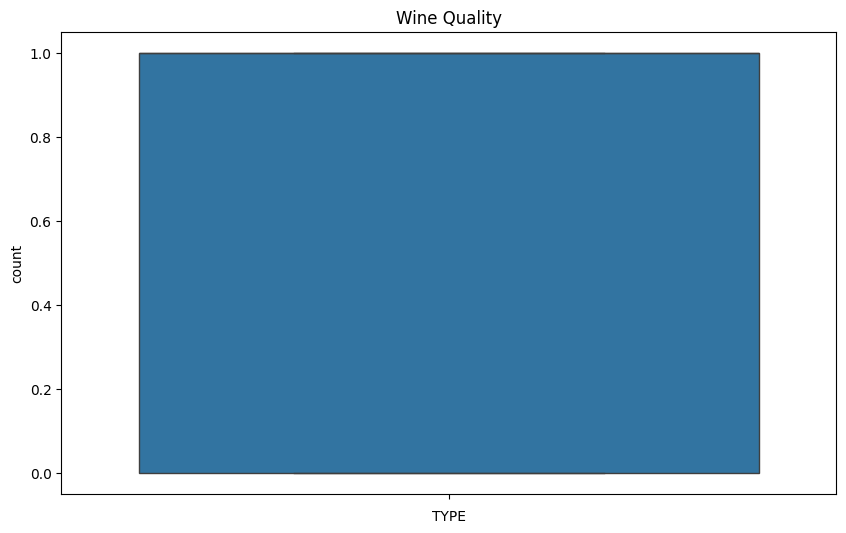

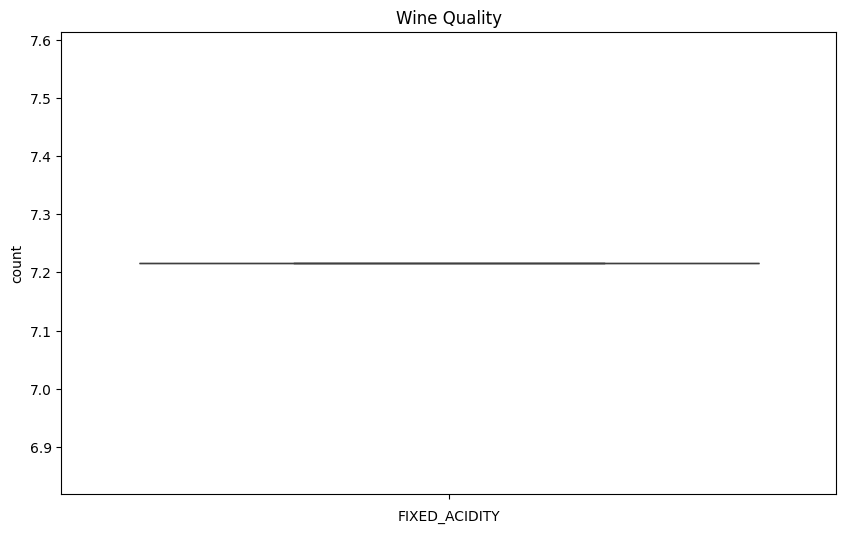

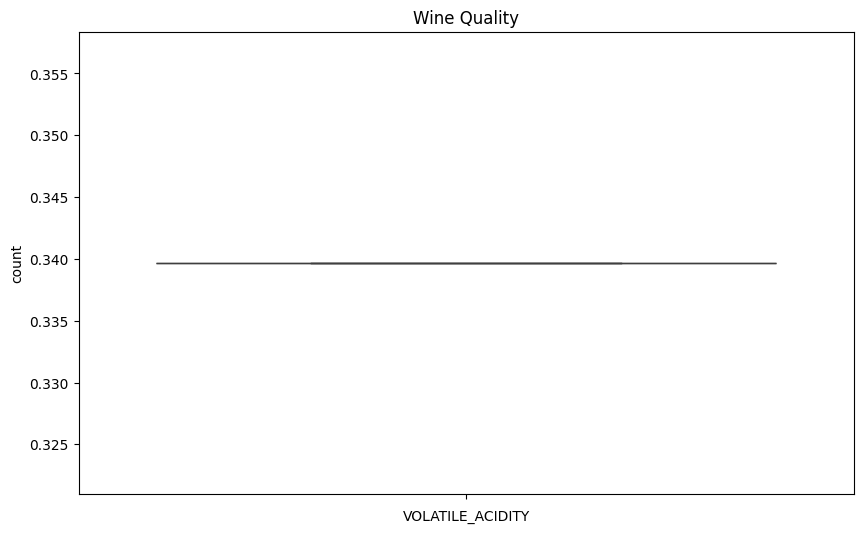

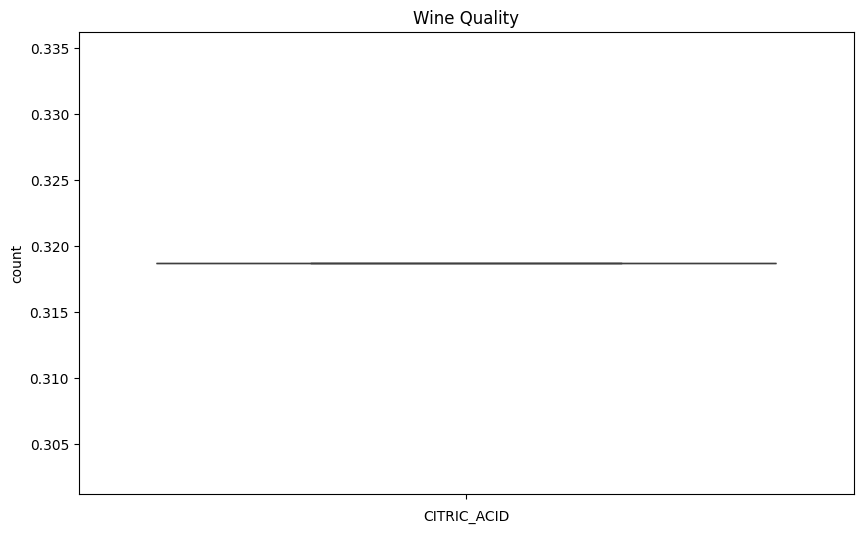

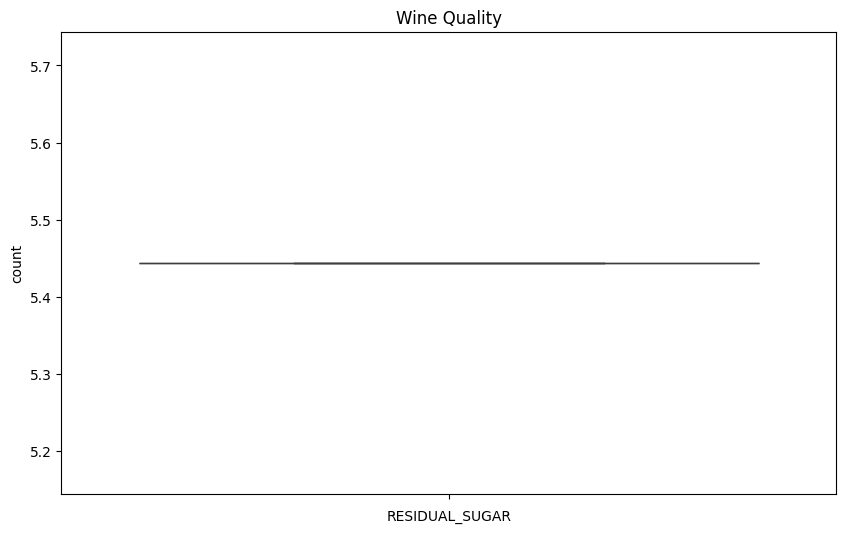

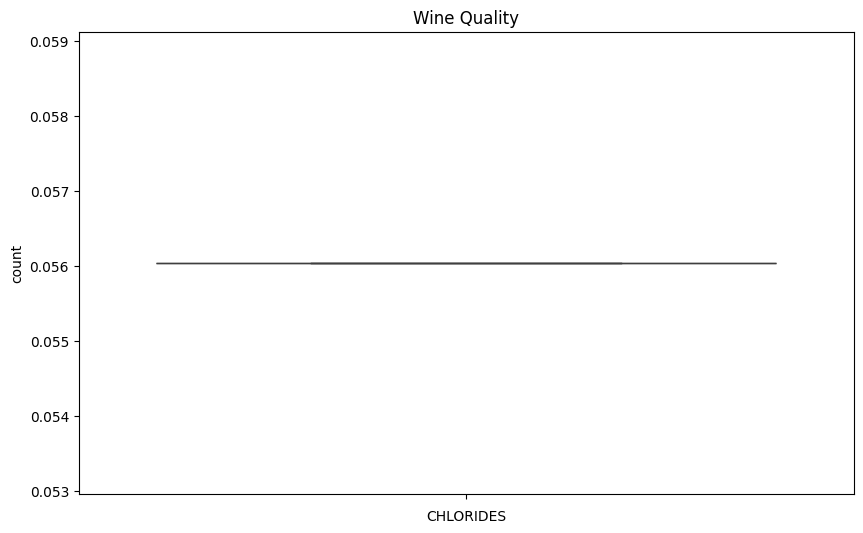

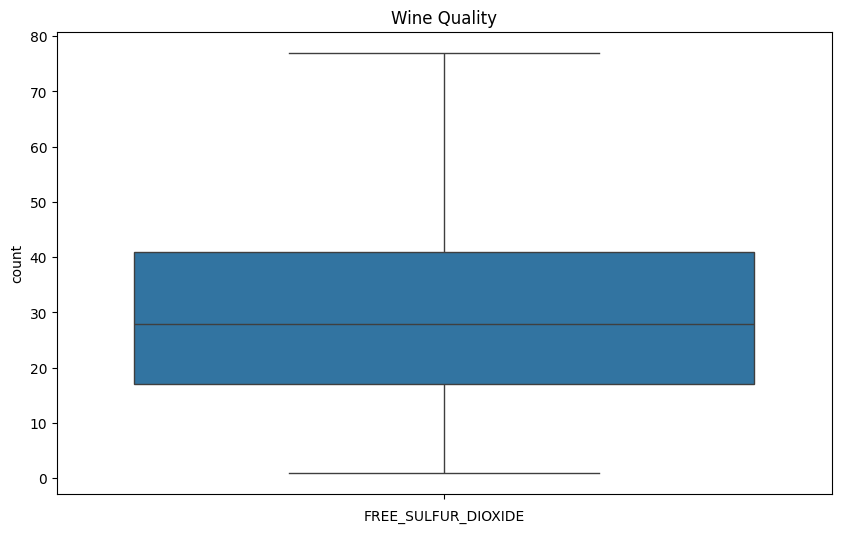

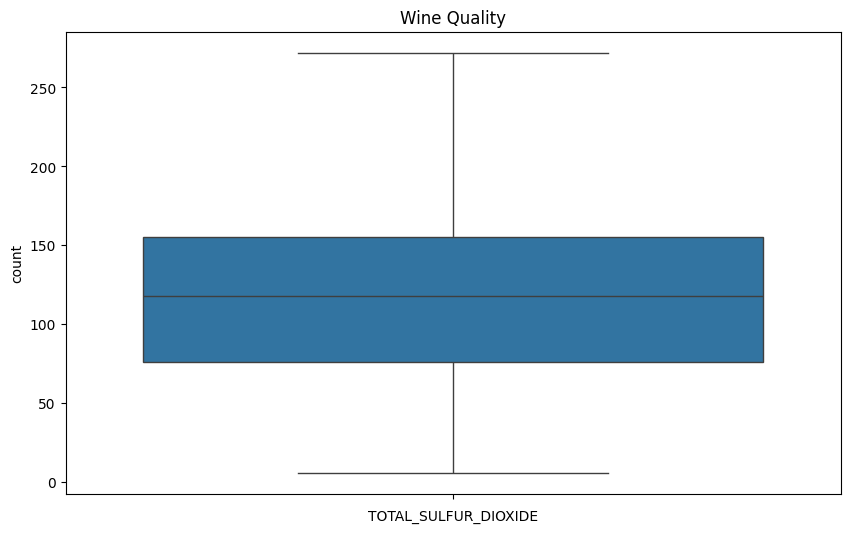

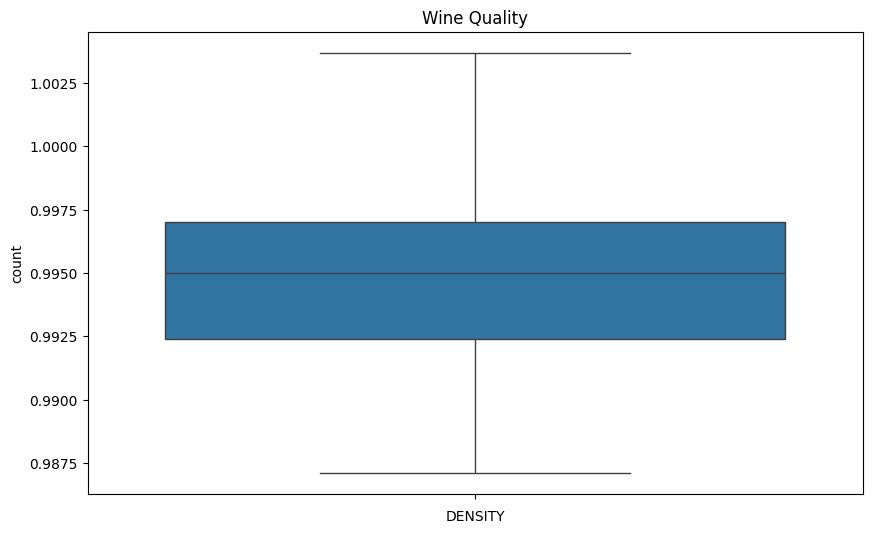

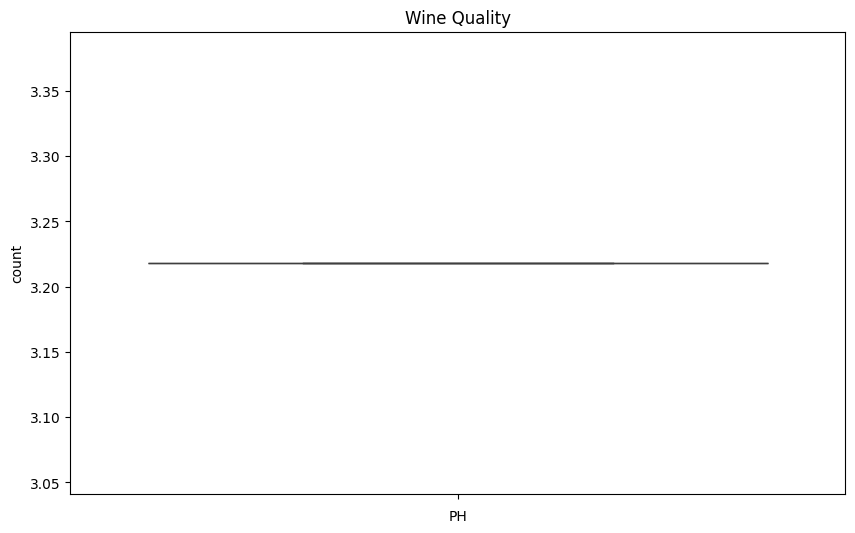

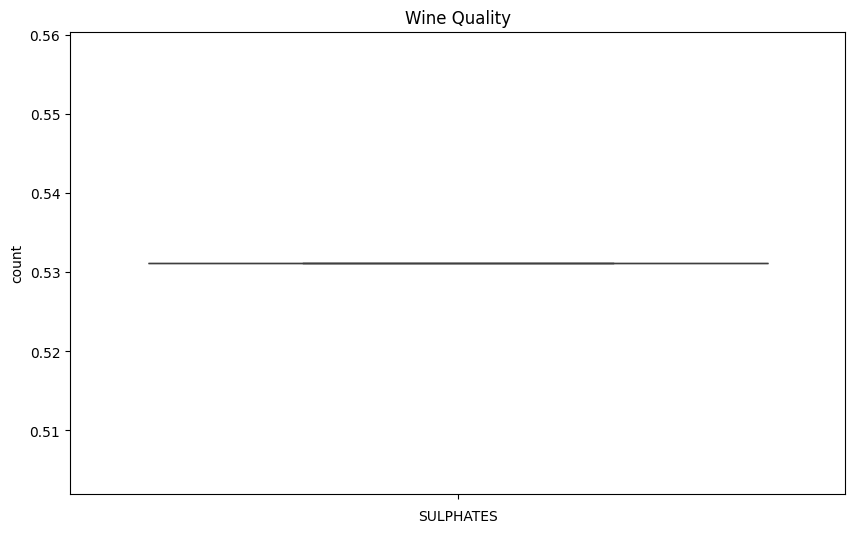

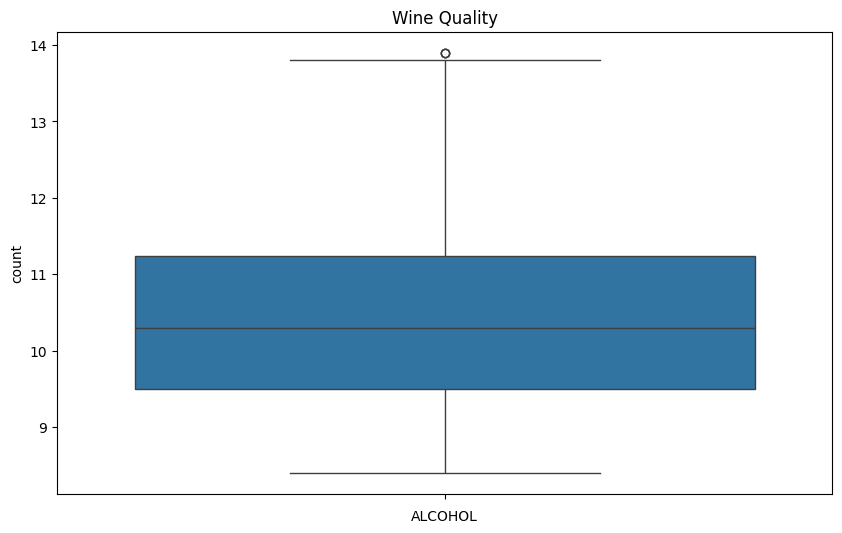

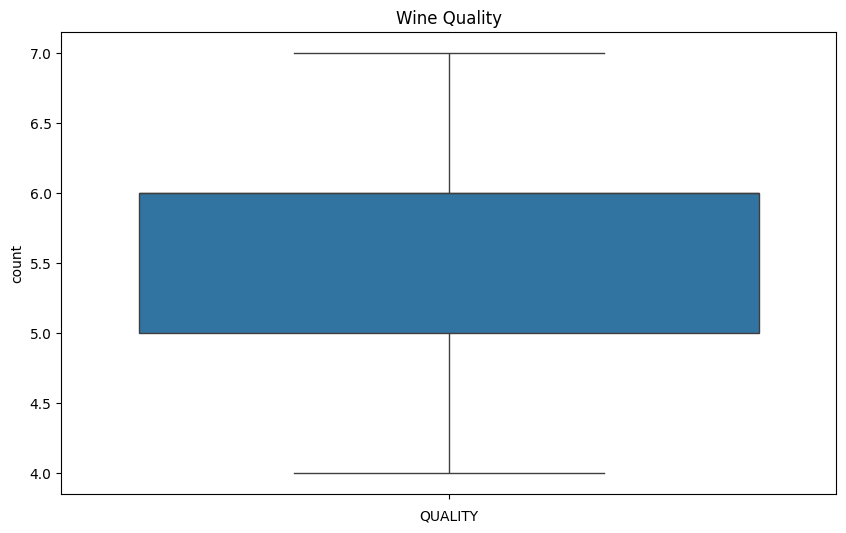

In [ ]:
for i in df.columns:
  if df[i].dtypes != 'object':
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title('Wine Quality')
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
out=['QUALITY','ALCOHOL','DENSITY','TOTAL_SULFUR_DIOXIDE','FREE_SULFUR_DIOXIDE']

In [ ]:
for i in out:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR = Q3-Q1

  lb=Q1-1.5*IQR
  ub=Q3+1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]

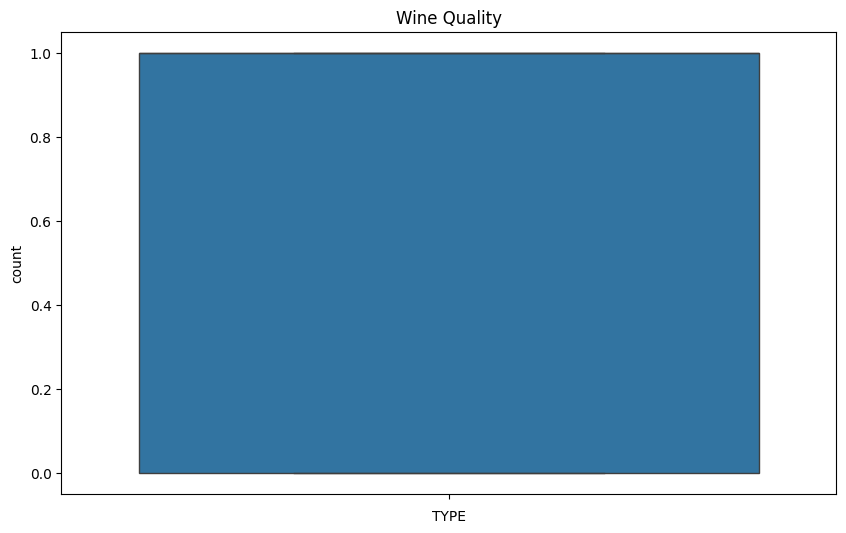

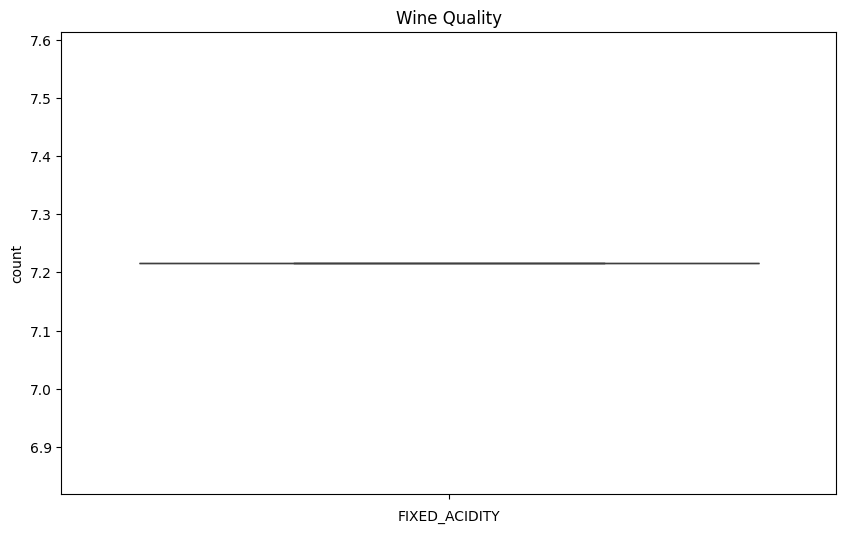

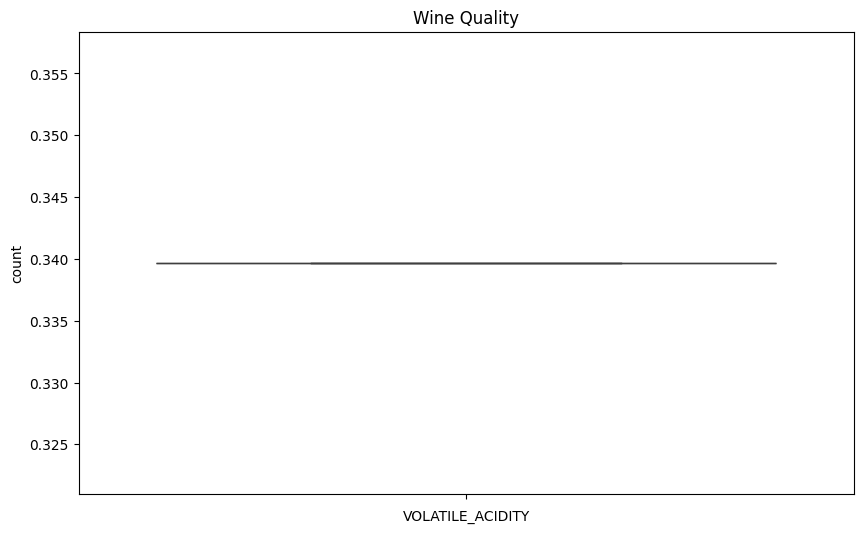

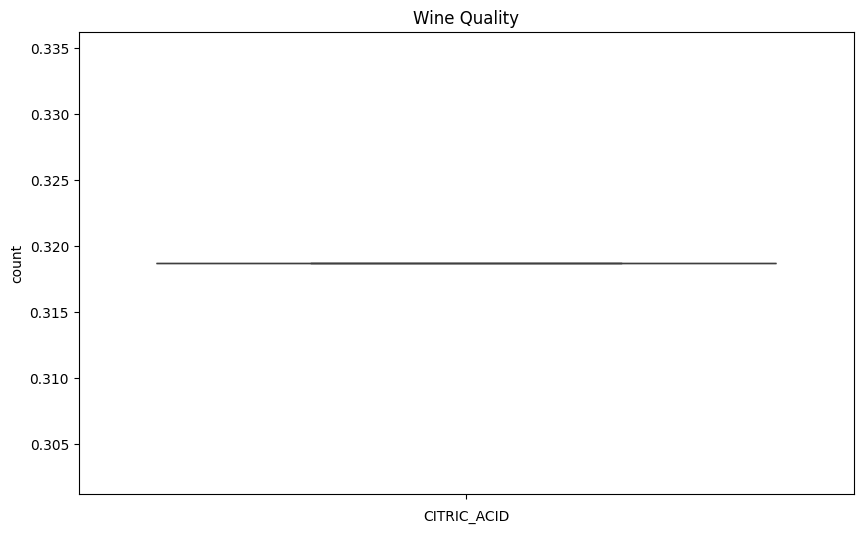

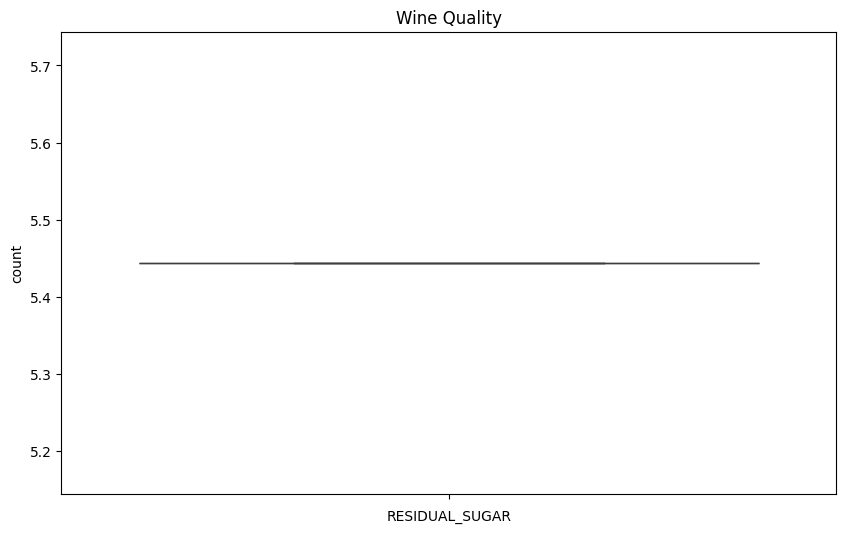

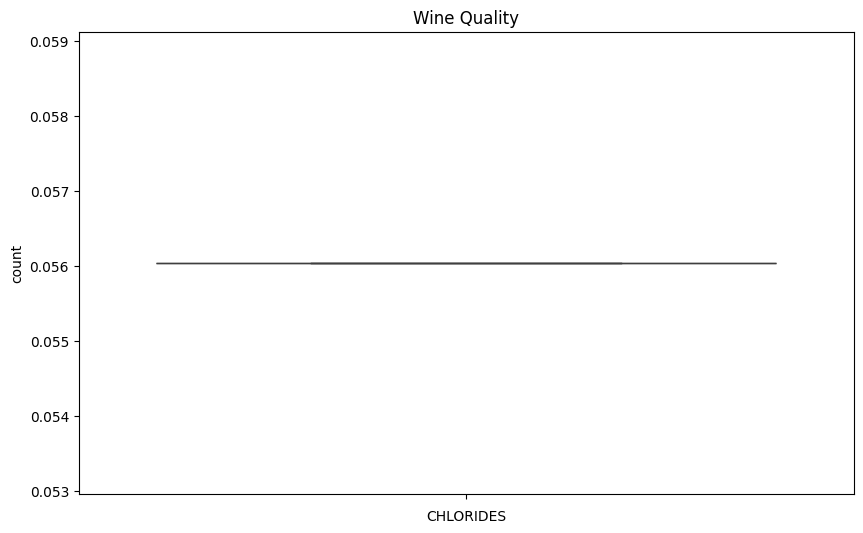

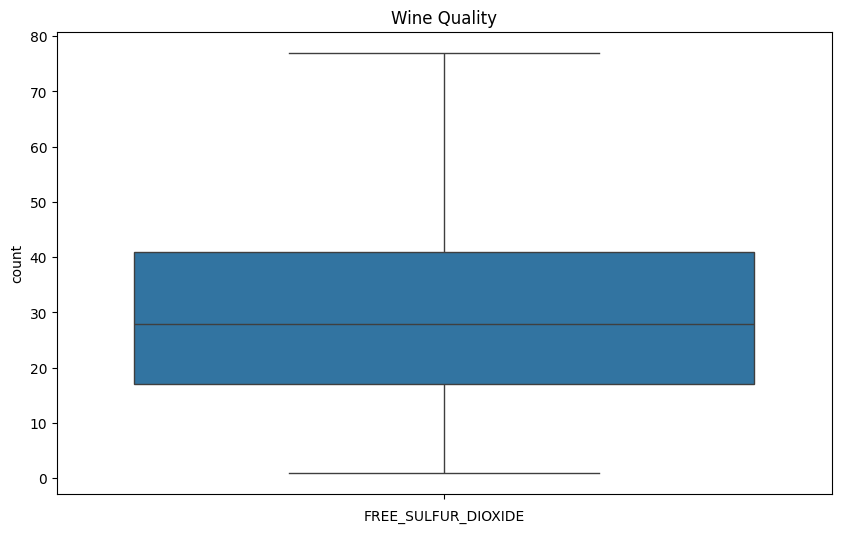

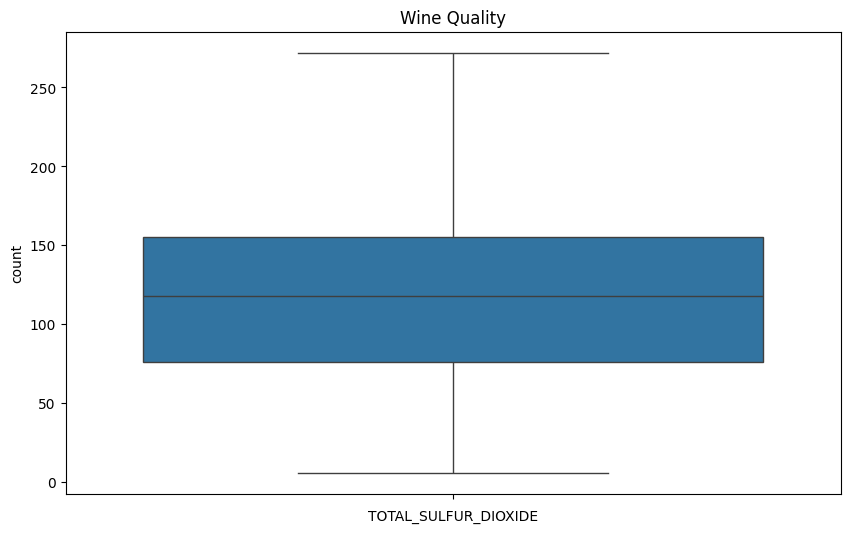

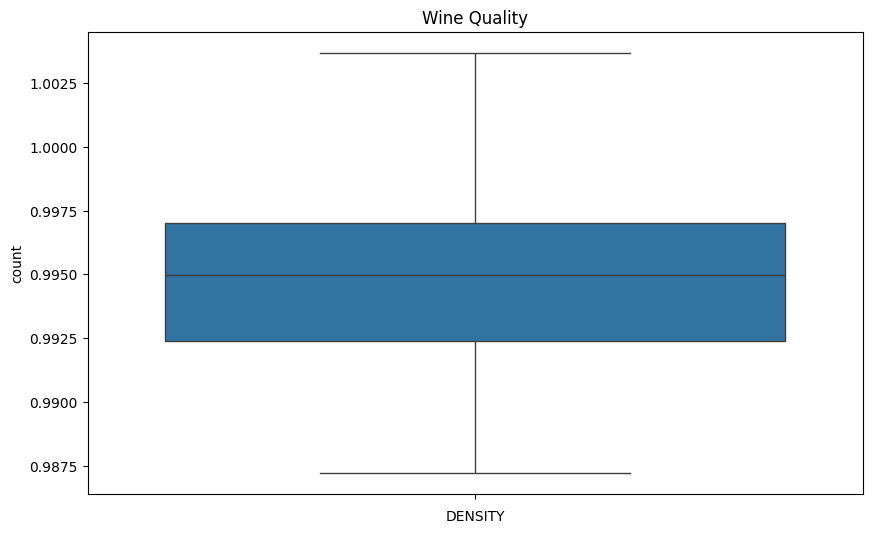

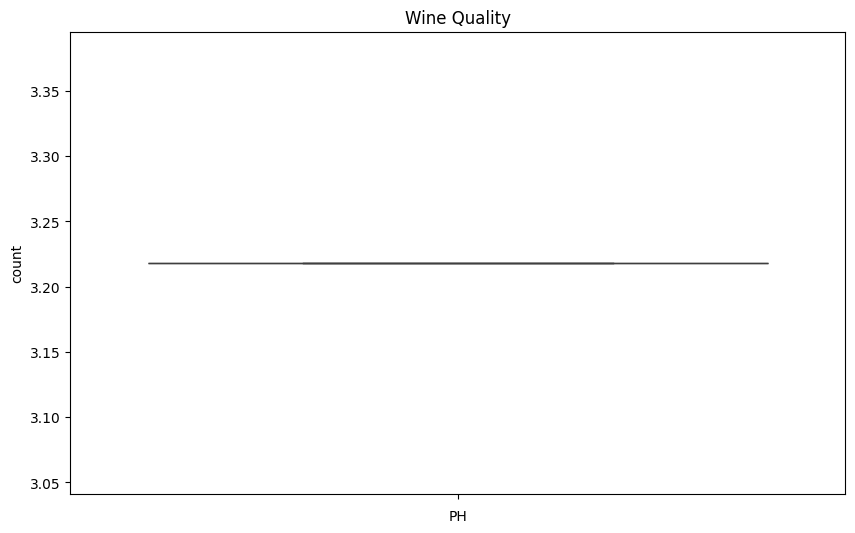

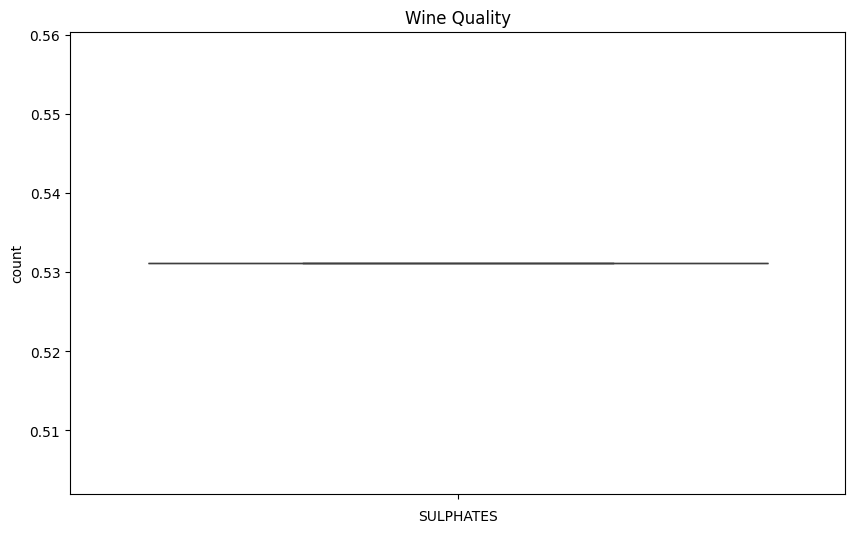

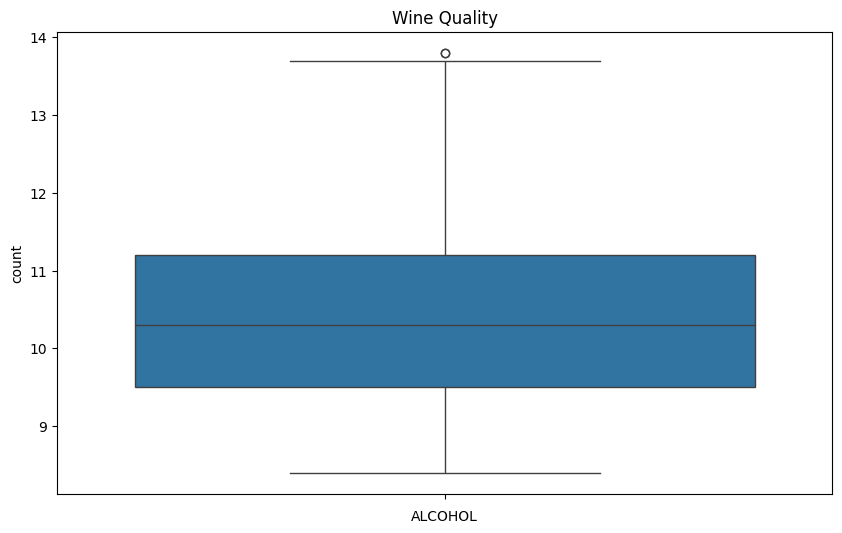

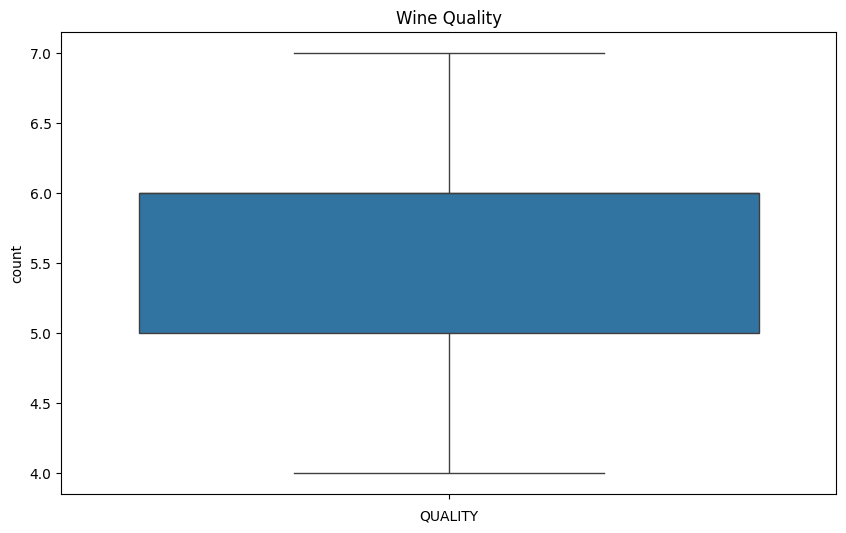

In [ ]:
for i in df.columns:
  if df[i].dtypes != 'object':
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title('Wine Quality')
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
df

,TYPE,FIXED_ACIDITY,VOLATILE_ACIDITY,CITRIC_ACID,RESIDUAL_SUGAR,CHLORIDES,FREE_SULFUR_DIOXIDE,TOTAL_SULFUR_DIOXIDE,DENSITY,PH,SULPHATES,ALCOHOL,QUALITY
0,1,7.216579,0.339691,0.318722,5.444326,0.056042,45.0,170.0,1.00100,3.218395,0.531215,8.8,6
1,1,7.216579,0.339691,0.318722,5.444326,0.056042,14.0,132.0,0.99400,3.218395,0.531215,9.5,6
2,1,7.216579,0.339691,0.318722,5.444326,0.056042,30.0,97.0,0.99510,3.218395,0.531215,10.1,6
3,1,7.216579,0.339691,0.318722,5.444326,0.056042,47.0,186.0,0.99560,3.218395,0.531215,9.9,6
4,1,7.216579,0.339691,0.318722,5.444326,0.056042,47.0,186.0,0.99560,3.218395,0.531215,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,7.216579,0.339691,0.318722,5.444326,0.056042,32.0,44.0,0.99490,3.218395,0.531215,10.5,5
6493,0,7.216579,0.339691,0.318722,5.444326,0.056042,39.0,51.0,0.99512,3.218395,0.531215,11.2,6
6494,0,7.216579,0.339691,0.318722,5.444326,0.056042,29.0,40.0,0.99574,3.218395,0.531215,11.0,6
6495,0,7.216579,0.339691,0.318722,5.444326,0.056042,32.0,44.0,0.99547,3.218395,0.531215,10.2,5


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == 'object':
    df[i]=le.fit_transform(df[i])
df

,TYPE,FIXED_ACIDITY,VOLATILE_ACIDITY,CITRIC_ACID,RESIDUAL_SUGAR,CHLORIDES,FREE_SULFUR_DIOXIDE,TOTAL_SULFUR_DIOXIDE,DENSITY,PH,SULPHATES,ALCOHOL,QUALITY
0,1,7.216579,0.339691,0.318722,5.444326,0.056042,45.0,170.0,1.00100,3.218395,0.531215,8.8,6
1,1,7.216579,0.339691,0.318722,5.444326,0.056042,14.0,132.0,0.99400,3.218395,0.531215,9.5,6
2,1,7.216579,0.339691,0.318722,5.444326,0.056042,30.0,97.0,0.99510,3.218395,0.531215,10.1,6
3,1,7.216579,0.339691,0.318722,5.444326,0.056042,47.0,186.0,0.99560,3.218395,0.531215,9.9,6
4,1,7.216579,0.339691,0.318722,5.444326,0.056042,47.0,186.0,0.99560,3.218395,0.531215,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,7.216579,0.339691,0.318722,5.444326,0.056042,32.0,44.0,0.99490,3.218395,0.531215,10.5,5
6493,0,7.216579,0.339691,0.318722,5.444326,0.056042,39.0,51.0,0.99512,3.218395,0.531215,11.2,6
6494,0,7.216579,0.339691,0.318722,5.444326,0.056042,29.0,40.0,0.99574,3.218395,0.531215,11.0,6
6495,0,7.216579,0.339691,0.318722,5.444326,0.056042,32.0,44.0,0.99547,3.218395,0.531215,10.2,5


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop('QUALITY', axis=1)
y = df['QUALITY']

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf,x,y,cv=5,scoring='accuracy')
print(scores.mean())

NameError: name 'rf' is not defined

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)
y_pred=dc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 0.6295399515738499


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
rc=RandomForestClassifier(n_estimators=300,max_depth=15,min_samples_split=5,min_samples_leaf=2,class_weight='balanced',random_state=42)
scores = cross_val_score(rc,x,y,cv=5,scoring='accuracy')
rc.fit(x_train,y_train)
y_pred=rc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 0.6464891041162227


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=5)
kn.fit(x_train,y_train)
y_pred=kn.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 0.5585149313962873


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

In [ ]:
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 0.5020177562550444


In [ ]:
y.value_counts()

,count
QUALITY,
6,2801
5,2115
7,1062
4,214
